# NewsBot Intelligence System

## Module 1: Business Context
## Module 2: Text Preprocessing
## Module 3: TF-IDF Feature Extraction
## Module 4: POS Tagging
## Module 5: Syntax Parsing
## Module 6: Sentiment Analysis
## Module 7: Text Classification
## Module 8: Named Entity Recognition
## Final Integration Pipeline

# NewsBot Intelligence System (Midterm Project)
## Module 1: Business Case
This system analyzes news articles to classify categories, extract entities, and analyze sentiment. It helps media companies and analysts monitor trends and insights efficiently.

In [2]:
# Install libraries
!pip install spacy textblob scikit-learn
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import pandas as pd
import numpy as np
import spacy
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

nlp = spacy.load('en_core_web_sm')

## Load Dataset

In [4]:
import json

# List to hold successfully parsed JSON objects
data = []

# Read the file line by line and parse each line as a JSON object
with open('/content/News_Category_Dataset_v3[1].json', 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")

df = pd.DataFrame(data)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/News_Category_Dataset_v3[1].json'

In [5]:
import zipfile

zip_file_path = '/content/News_Category_Dataset_v3.json.zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

'/content/News_Category_Dataset_v3.json.zip' unzipped to '/content/'


In [6]:
import json

# List to hold successfully parsed JSON objects
data = []

# Read the file line by line and parse each line as a JSON object
with open('/content/News_Category_Dataset_v3.json', 'r') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")

df = pd.DataFrame(data)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [9]:
df['content'] = df['headline'] + ' ' + df['short_description']
df[['headline', 'short_description', 'content']].head()

,headline,short_description,content
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Woman Who Called Cops On Black Bird-Watcher Lo...


## Module 2: Preprocessing

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['cleaned'] = df['content'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Module 3: TF-IDF

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['cleaned'])
y = df['category']

print("Top words:", tfidf.get_feature_names_out()[:20])

Top words: ['able' 'abuse' 'access' 'according' 'account' 'accused' 'across' 'act'
 'action' 'activist' 'actor' 'actress' 'actually' 'ad' 'add' 'address'
 'administration' 'adorable' 'adult' 'advice']


##Module 4: POS **Tagging**

In [12]:
docs = list(nlp.pipe(df['content'][:100], disable=["ner"]))

pos_results = []
for doc in docs:
    pos_results.append([(token.text, token.pos_) for token in doc[:10]])

df_subset = df.iloc[:100].copy()
df_subset['pos_tags'] = pos_results

df_subset['pos_tags'].head()

,pos_tags
0,"[(Over, ADP), (4, NUM), (Million, NUM), (Ameri..."
1,"[(American, PROPN), (Airlines, PROPN), (Flyer,..."
2,"[(23, NUM), (Of, ADP), (The, DET), (Funniest, ..."
3,"[(The, DET), (Funniest, PROPN), (Tweets, PROPN..."
4,"[(Woman, NOUN), (Who, PRON), (Called, VERB), (..."


##**Module 5: Syntax parsing**

In [14]:
docs = list(nlp.pipe(df['content'][:50], disable=["ner"]))

dep_results = []
for doc in docs:
    dep_results.append([(token.text, token.dep_, token.head.text) for token in doc[:10]])

df_subset = df.iloc[:50].copy()
df_subset['dependencies'] = dep_results

df_subset['dependencies'].head()

,dependencies
0,"[(Over, quantmod, Million), (4, compound, Mill..."
1,"[(American, compound, Airlines), (Airlines, co..."
2,"[(23, ROOT, 23), (Of, prep, 23), (The, det, Fu..."
3,"[(The, det, Funniest), (Funniest, nsubj, Tweet..."
4,"[(Woman, nsubj, Loses), (Who, nsubj, Called), ..."


## Module 6: Sentiment

In [17]:
sentiments = []

for text in df['content'][:100]:
    sentiments.append(TextBlob(text).sentiment.polarity)

df_subset = df.iloc[:100].copy()
df_subset['sentiment'] = sentiments

## Module 7:Classification

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Model 1: Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression(max_iter=200)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))

Logistic Regression Accuracy: 0.4972557628979144


## Model 2: Naive Bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB

model2 = MultinomialNB()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred2))

Naive Bayes Accuracy: 0.44778790626640574


## Module 8: NER

In [22]:
docs = list(nlp.pipe(df['content'][:50]))

entity_results = []
for doc in docs:
    entity_results.append([(ent.text, ent.label_) for ent in doc.ents])

df_subset = df.iloc[:50].copy()
df_subset['entities'] = entity_results

df_subset['entities'].head()

,entities
0,"[(171 million, CARDINAL), (U.S., GPE)]"
1,"[(American Airlines, ORG), (Flyer Charged, PER..."
2,"[(23, CARDINAL), (Sept. 17-23, DATE)]"
3,"[(This Week, DATE), (Sept. 17-23, DATE), (Taba..."
4,"[(Franklin Templeton, PERSON), (Central Park, ..."


##Module 9: Final Pipeline

In [23]:
def analyze_article(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])

    category = model1.predict(vector)[0]
    sentiment = TextBlob(text).sentiment.polarity
    entities = extract_entities(text)

    return {
        "Category": category,
        "Sentiment": sentiment,
        "Entities": entities[:5]
    }

##Visual

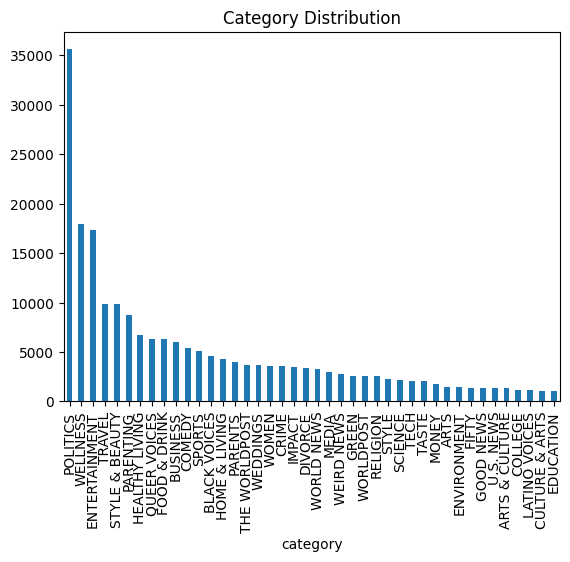

In [24]:
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()